In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
dataset.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


In [3]:
print(dataset.shape)
print(dataset.sum())

(10000, 10)
Ad 1     1703
Ad 2     1295
Ad 3      728
Ad 4     1196
Ad 5     2695
Ad 6      126
Ad 7     1112
Ad 8     2091
Ad 9      952
Ad 10     489
dtype: int64


In [4]:
X = dataset.values

# Label = index of clicked ad
y = np.argmax(X, axis=1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
[[839   0   0   0   0   0   0   0   0   0]
 [  0 221   0   0   0   0   0   0   0   0]
 [  0   0 103   0   0   0   0   0   0   0]
 [  0   0   0 161   0   0   0   0   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   0   0   0   0   6   0   0   0   0]
 [  0   0   0   0   0   0  92   0   0   0]
 [  0   0   0   0   0   0   0 171   0   0]
 [  0   0   0   0   0   0   0   0  57   0]
 [  0   0   0   0   0   0   0   0   0  28]]


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
[[839   0   0   0   0   0   0   0   0   0]
 [  0 221   0   0   0   0   0   0   0   0]
 [  0   0 103   0   0   0   0   0   0   0]
 [  0   0   0 161   0   0   0   0   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   0   0   0   0   6   0   0   0   0]
 [  0   0   0   0   0   0  92   0   0   0]
 [  0   0   0   0   0   0   0 171   0   0]
 [  0   0   0   0   0   0   0   0  57   0]
 [  0   0   0   0   0   0   0   0   0  28]]


In [8]:
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


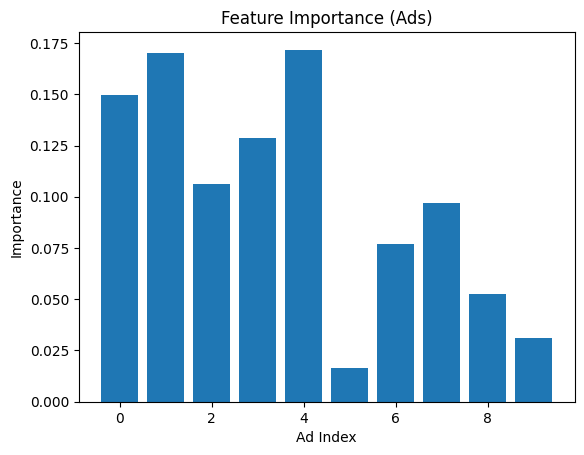

In [9]:
importances = rf_model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Ads)")
plt.xlabel("Ad Index")
plt.ylabel("Importance")
plt.show()

In [10]:
sample = X_test[0].reshape(1, -1)

print("Decision Tree Prediction:", dt_model.predict(sample))
print("Random Forest Prediction:", rf_model.predict(sample))

Decision Tree Prediction: [2]
Random Forest Prediction: [2]
